# Part 1: Baseline Models

This notebook trains and evaluates the two baselines for Part 1: a majority-class floor and a TF-IDF plus Logistic Regression classifier, both on the shared stratified split. Every output is followed by an explanation, so this notebook can be read on its own when writing the report.

Both models are scored with `src/metrics.py`, the same evaluation code every other part of the project uses, so these numbers are directly comparable to the neural models built in Parts 2 through 4.

In [1]:
import os
import sys

# Google Colab only: fetch the repo so the relative paths in this notebook resolve.
if 'google.colab' in sys.modules:
    if not os.path.exists('NLP-and-Language-Technologies'):
        get_ipython().system('git clone -q https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git')
    os.chdir('NLP-and-Language-Technologies/notebooks')

In [2]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

from src.baselines import load_train_val, run_majority_baseline, run_tfidf_logreg

train, val = load_train_val()
print(f'train size: {len(train)}')
print(f'val size: {len(val)}')

train size: 27755
val size: 5947


**What this shows:** 27,755 training rows and 5,947 validation rows, matching the 70/15 portion of the shared stratified split confirmed earlier in `src/data_prep.py`.

## Majority-class baseline

This model predicts the single most frequent training label, `sexual_violence`, for every example. It exists to make the class imbalance concrete: it is the floor any real model must clear, not a competitive model in its own right.

Model: majority_baseline
Accuracy (leaderboard metric): 0.8234
Macro F1: 0.1806
Weighted F1: 0.7437

Per-class precision / recall / F1 / support:
  economic_violence              precision=0.000  recall=0.000  f1=0.000  support=33
  emotional_violence             precision=0.000  recall=0.000  f1=0.000  support=97
  harmful_traditional_practice   precision=0.000  recall=0.000  f1=0.000  support=28
  physical_violence              precision=0.000  recall=0.000  f1=0.000  support=892
  sexual_violence                precision=0.823  recall=1.000  f1=0.903  support=4897


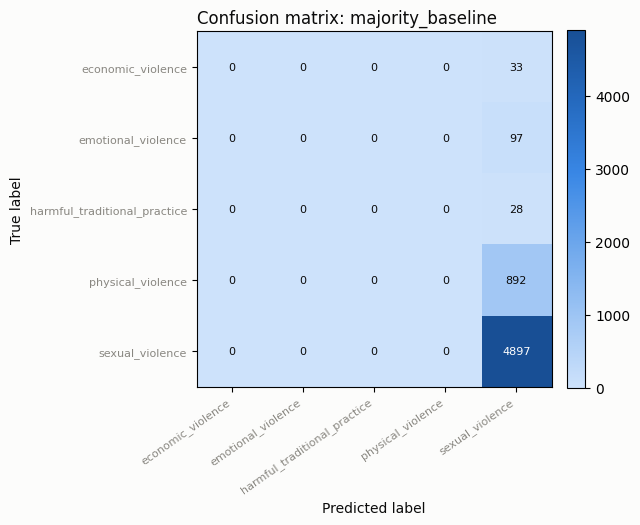

In [3]:
majority_metrics = run_majority_baseline(train, val)

**What this shows:** accuracy is 0.8234, matching the class distribution found in the EDA exactly, since this model always predicts `sexual_violence`. Macro F1 collapses to 0.1806, and every class other than `sexual_violence` scores exactly zero precision, recall, and F1. This is the numerical proof of the point made in Part 1's EDA: accuracy alone would call this an 82% correct model, while it has learned nothing at all about four of the five categories.

## TF-IDF and Logistic Regression

This model represents each tweet as TF-IDF weighted unigrams and bigrams, then classifies with logistic regression using balanced class weights, chosen because of the imbalance documented in the EDA, and tested directly against the unweighted alternative in a later section.

Model: tfidf_logreg
Accuracy (leaderboard metric): 0.9970
Macro F1: 0.9841
Weighted F1: 0.9970

Per-class precision / recall / F1 / support:
  economic_violence              precision=0.943  recall=1.000  f1=0.971  support=33
  emotional_violence             precision=0.915  recall=1.000  f1=0.956  support=97
  harmful_traditional_practice   precision=1.000  recall=1.000  f1=1.000  support=28
  physical_violence              precision=0.997  recall=0.996  f1=0.996  support=892
  sexual_violence                precision=0.999  recall=0.997  f1=0.998  support=4897


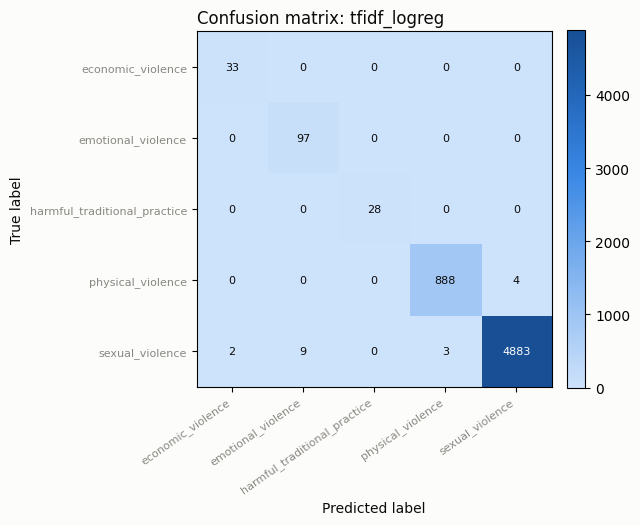

In [4]:
tfidf_metrics = run_tfidf_logreg(train, val)

**What this shows:** accuracy reaches 0.9970 and macro F1 reaches 0.9841, with every class scoring above 0.94 on precision, recall, and F1, including the two rarest classes. This is a strikingly strong result for a linear bag-of-words model on a 5-class problem, high enough that it needs to be investigated rather than simply reported. The investigation immediately below explains why.

## Class weights: on or off

The balanced class weights above were chosen because the dataset is heavily imbalanced, but that choice should be tested rather than assumed. The same model is trained below with no class weights and compared on validation only. The test split is not used for this decision.

Model: tfidf_logreg_unweighted
Accuracy (leaderboard metric): 0.9906
Macro F1: 0.9000
Weighted F1: 0.9900

Per-class precision / recall / F1 / support:
  economic_violence              precision=1.000  recall=0.818  f1=0.900  support=33
  emotional_violence             precision=1.000  recall=0.753  f1=0.859  support=97
  harmful_traditional_practice   precision=1.000  recall=0.607  f1=0.756  support=28
  physical_violence              precision=0.999  recall=0.984  f1=0.992  support=892
  sexual_violence                precision=0.989  recall=1.000  f1=0.994  support=4897



class weights   : macro F1 0.9841, 18 validation errors
no class weights: macro F1 0.9000, 56 validation errors


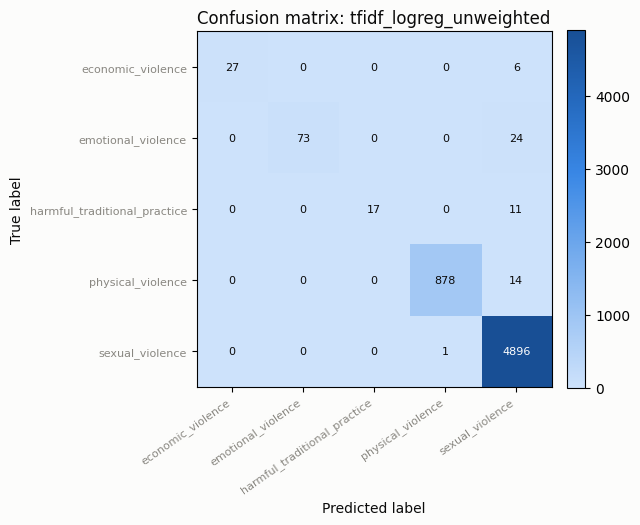

In [5]:
unweighted_metrics = run_tfidf_logreg(train, val, class_weight=None, name='tfidf_logreg_unweighted')

cm_w = tfidf_metrics['confusion_matrix']
cm_u = unweighted_metrics['confusion_matrix']
print()
print(f"class weights   : macro F1 {tfidf_metrics['macro_f1']:.4f}, {int(cm_w.sum() - cm_w.trace())} validation errors")
print(f"no class weights: macro F1 {unweighted_metrics['macro_f1']:.4f}, {int(cm_u.sum() - cm_u.trace())} validation errors")

**What this shows:** class weights matter a great deal for this model. Without them macro F1 falls from 0.9841 to 0.9000 and validation errors rise from 18 to 56, almost all on the rare classes: recall drops to 0.607 for `harmful_traditional_practice`, 0.753 for `emotional_violence`, and 0.818 for `economic_violence`, while precision on those classes stays at 1.000. The unweighted model does not collapse to the majority class, but it is too cautious about the rare ones, which is exactly what macro F1 punishes and accuracy hides (accuracy only moves from 0.9970 to 0.9906). The weighted configuration is kept. This result is specific to a linear model: in Part 4 the fine-tuned DistilBERT scored higher on validation without class weights (0.9997 versus 0.9950), so the effect of class weights has to be tested for each model rather than assumed.

## Why the TF-IDF baseline scores this high

The challenge brief explicitly frames this task as classification "without using keywords." A near-perfect linear bag-of-words model is a signal that the categories may be separable by a small set of near-deterministic trigger words, which is exactly the shortcut the brief warns against. This is checked directly below by reading off the highest-weighted features the trained model actually relies on for each class.

In [6]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from src.data_prep import ID_TO_LABEL

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X = vec.fit_transform(train['tweet_clean'])
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X, train['label_id'])

feature_names = np.array(vec.get_feature_names_out())
for class_id in range(5):
    top_idx = np.argsort(clf.coef_[class_id])[-10:][::-1]
    print(f"{ID_TO_LABEL[class_id]}: {list(feature_names[top_idx])}")

economic_violence: ['fired', 'job', 'because', 'woman', 'was fired', 'fired from', 'was', 'job because', 'my job', 'boss']
emotional_violence: ['public', 'humiliated', 'insulted', 'in public', 'in', 'verbally', 'humiliated me', 'the public', 'insulted me', 'verbally abused']
harmful_traditional_practice: ['forced', 'fgm', 'marriage', 'child marriage', 'undergo', 'genital mutilation', 'genital', 'female genital', 'mutilation', 'child']
physical_violence: ['beats', 'husband', 'my husband', 'beats me', 'my', 'husband beats', 'he beats', 'beats the', 'beats her', 'wife']
sexual_violence: ['raped', 'he', 'raped me', 'he raped', 'was raped', 'rape', 'raped and', 'raped by', 'me', 'raped her']


**What this shows:** the top features driving each class are close to literal trigger words. `raped` and `rape` drive `sexual_violence`, `fgm`, `mutilation`, and `child marriage` drive `harmful_traditional_practice`, `beats` and `husband` drive `physical_violence`, `fired`, `job`, and `boss` drive `economic_violence`, and `humiliated`/`insulted` drive `emotional_violence`. This confirms the model is closer to a keyword lookup table than to genuine language understanding, and it explains the near-perfect score directly: this dataset's categories are largely separable by a narrow, learnable vocabulary.

This has a direct consequence for the rest of the project. This TF-IDF baseline is not a weak strawman to be easily beaten; on this validation set it may be difficult for any model to substantially outscore it on accuracy or macro F1 using the same kind of evaluation. The genuinely useful comparison for the neural models in Parts 2 through 4 is therefore not only the headline metric, but whether they generalize better than this baseline on the harder subset of examples that do not contain an obvious trigger word, an angle worth building into the shared error analysis in a later stage.

## Final test evaluation and saved predictions

The class-weight choice above was made on validation, so the test split can now be scored once. `run_tfidf_final` repeats the validation comparison, keeps the better configuration, scores the test split a single time, and saves the per-tweet class probabilities in the shared format used by every model (`reports/results/preds_tfidf_logreg_test.csv`). The probabilities are kept so that ROC curves and error analysis can be done in the cross-model comparison without retraining anything.

chosen on validation: balanced

Model: tfidf_logreg (test)
Accuracy (leaderboard metric): 0.9970
Macro F1: 0.9813
Weighted F1: 0.9970

Per-class precision / recall / F1 / support:
  economic_violence              precision=0.941  recall=1.000  f1=0.970  support=32
  emotional_violence             precision=0.925  recall=1.000  f1=0.961  support=98
  harmful_traditional_practice   precision=0.966  recall=1.000  f1=0.982  support=28
  physical_violence              precision=0.996  recall=0.996  f1=0.996  support=892
  sexual_violence                precision=0.999  recall=0.997  f1=0.998  support=4898


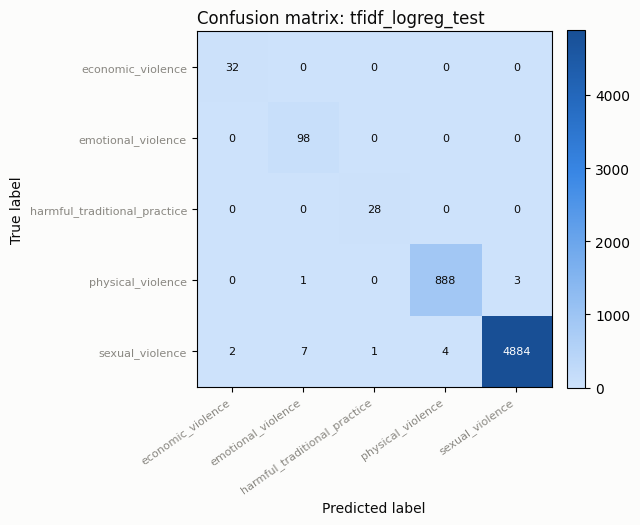

In [7]:
from src.baselines import load_train_val_test, run_tfidf_final
from src.metrics import compute_metrics, format_metrics_report

train, val, test = load_train_val_test()
final = run_tfidf_final(train, val, test)
print('chosen on validation:', final['chosen'])
print()
print(format_metrics_report(final['test_metrics'], 'tfidf_logreg (test)'))

**What this shows:** validation again selects the class-weighted configuration, and the single test evaluation gives 99.70% accuracy and a macro F1 of 0.9813, close to the validation result (0.9970 and 0.9841). Recall is perfect for all three rare classes on test, so the remaining errors are other tweets being pulled into them: precision is 0.925 for `emotional_violence`, 0.941 for `economic_violence`, and 0.966 for `harmful_traditional_practice`. For `economic_violence` and `emotional_violence` this is the same pattern seen on validation, and it is what heavy class weights tend to produce. The per-tweet probabilities are now saved in `reports/results/preds_tfidf_logreg_test.csv`, which lets this baseline join the cross-model comparison.

## Leak-free check

The EDA found that about 2% of validation and test tweets have a near-identical copy in the training split. A model can score those rows by memorization, so this check scores the same predictions a second time on only the rows with no copy in train, using the shared definition in `src/leakage.py`.

In [8]:
import pandas as pd
from src.leakage import load_merged, leak_free_ids

merged = load_merged()
pipeline = final['pipeline']

rows = []
for name, data, keep_ids in [
    ('val', val, leak_free_ids(merged, 'val')),
    ('test', test, leak_free_ids(merged, 'test')),
]:
    preds = pipeline.predict(data['tweet_clean'])
    y = data['label_id'].values
    keep = data['Tweet_ID'].isin(keep_ids).values
    all_rows = compute_metrics(y, preds)
    clean_rows = compute_metrics(y[keep], preds[keep])
    rows.append({
        'split': name,
        'rows': len(data),
        'leak_free_rows': int(keep.sum()),
        'accuracy': all_rows['accuracy'],
        'accuracy_leak_free': clean_rows['accuracy'],
        'macro_f1': all_rows['macro_f1'],
        'macro_f1_leak_free': clean_rows['macro_f1'],
    })

pd.DataFrame(rows).round(4)

,split,rows,leak_free_rows,accuracy,accuracy_leak_free,macro_f1,macro_f1_leak_free
0,val,5947,5817,0.997,0.9969,0.9841,0.9837
1,test,5948,5831,0.997,0.9969,0.9813,0.9808


**What this shows:** removing the rows that have a copy in train barely changes the scores. On validation, macro F1 moves from 0.9841 to 0.9837 and accuracy from 0.9970 to 0.9969 (5,817 of 5,947 rows kept). On test, macro F1 moves from 0.9813 to 0.9808 and accuracy from 0.9970 to 0.9969 (5,831 of 5,948 rows kept). TF-IDF with Logistic Regression is a model that can profit from memorized text, so a change this small means the duplicate tweets are not inflating this model's results in a meaningful way. The headline numbers are therefore reported as they are, with the leak-free score alongside as a check.

## Summary: what this means going forward

The majority-class baseline confirms, numerically, that accuracy alone is not a trustworthy metric on this dataset. The TF-IDF and Logistic Regression baseline is unexpectedly strong, and the reason is traceable directly to a small set of near-deterministic keywords per class, exactly the shortcut the challenge brief warns against. Both results are saved to `reports/results/` in the shared JSON format, and both confusion matrices are saved to `reports/figures/`, ready for the five-model comparison in the Results and Visualizations stage. The most important open question this raises for Parts 2 through 4 is not whether a neural model can beat this baseline's headline score, but whether it can do something this baseline structurally cannot: generalize to tweets that describe these categories without using the obvious trigger words.

**Class weights, the test result, and saved predictions.** Class weights are worth keeping for this model: on validation, macro F1 is 0.9841 with them and 0.9000 without. With that choice fixed on validation, the single test evaluation gives 99.70% accuracy and 0.9813 macro F1, and the per-tweet probabilities are saved for the cross-model comparison. Scoring only the rows with no copy in the training split changes macro F1 by 0.0005 or less, so duplicate tweets across splits are not inflating these results.